# Этап 1. Расчет геометрии ТРТ и сопла

In [301]:
from math import *
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from scipy.integrate import quad
from scipy.optimize import bisect, fsolve

import importlib

import lib_Star
# Принудительная перезагрузка модуля
importlib.reload(lib_Star)
# Теперь импортируем класс
from lib_Star import Star, Star_2

import lib_GDF
# Принудительная перезагрузка модуля
importlib.reload(lib_GDF)
# Теперь импортируем класс
from lib_GDF import tay_gdf, epsilon_gdf, pi_gdf, q_gdf, z_gdf

import lib_zeta
# Принудительная перезагрузка модуля
importlib.reload(lib_zeta)
# Теперь импортируем класс
from lib_zeta import zeta

In [302]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

In [303]:
# Настройка pandas для отображения всех строк и столбцов
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [304]:
#name = 'test' # 0.2
#name = 'probnic' 
#name = 'С-5' # 0.057
#name = 'С-8' # 0.08
#name = 'С-13' # 0.122
name = '9М27Ф' # 0.22
#name = 'С-24' # 0.24
#name = '9М55' # 0.3
#name = 'Х-15' # 0.455

In [305]:
# Загрузка данных из dataset_1.csv
if name == 'test' or name == 'probnic':
    ds = pd.read_csv('dataset_1_test.csv').set_index('key').to_dict()
else:
    ds = pd.read_csv('dataset_1.csv').set_index('key').to_dict()

ds_values = ds['value']
ds_converted = {}
for key, value in ds_values.items():
    try:
        ds_converted[key] = float(value)
    except (ValueError, TypeError):
        ds_converted[key] = value

[grain, par_1, par_2, par_3,p_a, p_h, T_0_min, T_0_norm, T_0_max,bar_e_0_step,bar_e_0_min,bar_e_0_max,p_nom_step,p_nom_min,p_nom_max,chi,mu_s] = list(ds_converted.values())


In [306]:
# Загрузка данных о топливе
#propellant = pd.read_csv('propellant test.csv').set_index('propellant').T
propellant = pd.read_csv('propellant 13ПБГГ_87ПХА.csv').set_index('propellant').T
class Propellant:
    def __init__(self, df):
        for key in df.index:
            setattr(self, key, df[key])

pr = Propellant(propellant.iloc[0])

In [307]:
# Правильная загрузка Excel файла
df = pd.read_excel('Образцы.xlsx', sheet_name='Лист1')

# Переименуем колонки для удобства работы
df.columns = ['name', 'D_n']

print("Данные из Excel:")
print(df)
print(f"\nКолонки: {df.columns.tolist()}")

class Sample:
    def __init__(self, df, sample_name):
        # Создаем словарь для хранения данных всех образцов
        self.samples = {}
        
        for idx, row in df.iterrows():
            # Сохраняем данные каждого образца по его названию
            self.samples[row['name']] = {
                'D_n': row['D_n']
                
            }
        
        # Если запрошенный образец существует, сохраняем его данные как атрибуты объекта
        if sample_name in self.samples:
            self.D_n = self.samples[sample_name]['D_n']
            
            print(f"Найден образец: {sample_name}")
        else:
            print(f"Образец '{sample_name}' не найден!")
            print(f"Доступные образцы: {list(self.samples.keys())}")
            self.D_n = None
            

# Маппинг названий (как в коде -> как в Excel)
name_mapping = {
    'test':'Test',
    'probnic':'Probnic',
    'С-5': 'НАР С-5',
    'С-8': 'НАР С-8',
    'С-13': 'НАР С-13',
    '9М27Ф': '"Ураган" 9М27Ф',
    'С-24': 'НАР С-24',
    '9М55': '"Смерч" 9М55',
    'Х-15': 'Авиационная аэробаллистическая ракета Х-15'
}

# Получаем правильное название из файла
sample_full_name = name_mapping.get(name, name)
print(f"Ищем образец: {sample_full_name}")

# Создаем объект Sample
m = Sample(df, sample_full_name)

# Проверяем и выводим результаты
if m.D_n is not None:
    print(f"D_n: {m.D_n} м")
    
    
    # Продолжаем расчеты
    D_ks = np.round(0.96 * m.D_n, 4)
    D_n = m.D_n
    print(f"D_n = {D_n} м,D_ks = {D_ks} м")
else:
    print("Не удалось загрузить данные образца!")

Данные из Excel:
                                         name     D_n
0                                        Test  0.2000
1                                     Probnic  0.1727
2                                     НАР С-5  0.0570
3                                     НАР С-8  0.0800
4                                    НАР С-13  0.1220
5                              "Ураган" 9М27Ф  0.2200
6                                    НАР С-24  0.2400
7                                "Смерч" 9М55  0.3000
8  Авиационная аэробаллистическая ракета Х-15  0.4550

Колонки: ['name', 'D_n']
Ищем образец: "Ураган" 9М27Ф
Найден образец: "Ураган" 9М27Ф
D_n: 0.22 м
D_n = 0.22 м,D_ks = 0.2112 м


In [308]:
results_1 = {
    'Name':name,
    'bar_e_0': [],
    'omega_t':[],
    'D_ks_mm':[],
    
    'e_0_mm': [],
    'l_zar': [],
    'r_mm': [],
    'kappa_0':[],
    'xi_degr':[],
    'eps_f':[]
}


In [309]:
# par_1 = n (количество лучей звезды)
# par_2 = beta (угол)
# par_3 = bar_r (относительный радиус скругления)
n = par_1
bar_r = par_3

# Максимально допустимое значение f_a
f_a_max = 0.9

In [310]:
# Функция для решения уравнения относительно beta
def f_beta(beta_val):
    return pi/2 + pi/n - beta_val - 1/np.tan(beta_val)

# Решаем уравнение для beta методом половинного деления
a_beta = 0.001
b_beta = pi/2 - 0.001

try:
    bet = bisect(f_beta, a_beta, b_beta, xtol=1e-6)
    bet = round(bet*180/pi,2)
    bet = bet*pi/180
    print(f"Рассчитано beta = {bet} рад ({np.degrees(bet)}°) для n = {n}")
except ValueError as e:
    print(f"Ошибка при поиске корня: {e}")
    bet = par_2  # используем значение из файла как запасной вариант


Рассчитано beta = 0.6206390820091836 рад (35.56°) для n = 7.0


In [311]:
if name == 'test' or name == 'probnic':
    bet = 35.56*pi/180


In [312]:
bar_e_0_range = np.arange(bar_e_0_min, bar_e_0_max+bar_e_0_step/2, bar_e_0_step)
print(f"Диапазон bar_e_0: {bar_e_0_range}")
print(f"Количество значений bar_e_0: {len(bar_e_0_range)}")

Диапазон bar_e_0: [0.29  0.325 0.36 ]
Количество значений bar_e_0: 3


In [313]:
kappa_0_max = 85

for bar_e_0 in bar_e_0_range:
    bar_R = (1-bar_e_0)/(bar_r+1)
    alfa = pi / n
    bar_e_1 =  bar_R * (sin(alfa)/cos(bet)-bar_r)
    e_0 = bar_e_0*D_ks/2        
    if bar_e_0>=bar_e_1:
        R = bar_R*D_ks/2
        r = bar_r*R
        star = Star(
        D=D_ks,  
        e_0=e_0,
        rho_t=pr.rho,
        kappa_0_max=kappa_0_max,
        n=n,
        beta=bet,  # используем рассчитанное значение beta
        r=r
    )

        # Получаем вычисленные параметры
        star_params = star.get_params()

    # Извлекаем нужные параметры
    eps_f = star_params['eps_f']
    omega_t = star_params['omega_t']
    l = star_params['l']
    xi_degr = star_params['xi_degr']
    kappa_0 = star_params['kappa_0']

    # Сохранение результатов
    results_1['bar_e_0'].append(bar_e_0)  
    results_1['omega_t'].append(omega_t)
    results_1['D_ks_mm'].append(D_ks * 1e3)
    results_1['e_0_mm'].append(e_0 * 1e3)

    results_1['l_zar'].append(star.l)
    results_1['r_mm'].append(r * 1e3)

    results_1['kappa_0'].append(star.kappa_0)
    results_1['xi_degr'].append(xi_degr)
    results_1['eps_f'].append(eps_f)
    


In [314]:
# Подготовка данных для отображения
results_1_display = {
    'Name':name,
    'bar_e_0': [],
    'omega_t':[],
    'D_ks_mm':[],
    
    'e_0_mm': [],
    'l_zar': [],
    'r_mm': [],
    'kappa_0':[],
    'xi_degr':[],
    'eps_f':[]
}

In [315]:
for i in range(len(results_1['bar_e_0'])):
    results_1_display['bar_e_0'].append(results_1['bar_e_0'][i])
    results_1_display['omega_t'].append(results_1['omega_t'][i])
    results_1_display['D_ks_mm'].append(results_1['D_ks_mm'][i])
    
    results_1_display['e_0_mm'].append(results_1['e_0_mm'][i])
    
    results_1_display['l_zar'].append(results_1['l_zar'][i])
    results_1_display['r_mm'].append(results_1['r_mm'][i])
    
    results_1_display['kappa_0'].append(results_1['kappa_0'][i])
    results_1_display['xi_degr'].append(results_1['xi_degr'][i])
    results_1_display['eps_f'].append(results_1['eps_f'][i])
    
df_results_1_display = pd.DataFrame(results_1_display)

In [316]:
floatfmt_1 = [
    "",        # Name
    ".3f",     # bar_e_0
    ".1f",     # omega_t
    ".1f",     # D_ks_mm
    ".1f",     # e_0_mm
    ".4f",     # l_zar
    ".1f",     # r_mm
    ".3f",     # kappa_0
    ".5f",     # xi_degr
    ".5f"      # eps_f
    
]

In [317]:
table_str_1 = tabulate(
    df_results_1_display,
    headers='keys',
    tablefmt='grid',
    floatfmt=floatfmt_1,
    showindex=False
)
print(table_str_1)

+--------+-----------+-----------+-----------+----------+---------+--------+-----------+-----------+---------+
| Name   |   bar_e_0 |   omega_t |   D_ks_mm |   e_0_mm |   l_zar |   r_mm |   kappa_0 |   xi_degr |   eps_f |
+========+===========+===========+===========+==========+=========+========+===========+===========+=========+
| 9М27Ф  |     0.290 |      47.6 |     211.2 |     30.6 |  1.0747 |    6.8 |        85 |   0.16242 | 0.74306 |
+--------+-----------+-----------+-----------+----------+---------+--------+-----------+-----------+---------+
| 9М27Ф  |     0.325 |      46.7 |     211.2 |     34.3 |  1.0217 |    6.5 |        85 |   0.13516 | 0.76777 |
+--------+-----------+-----------+-----------+----------+---------+--------+-----------+-----------+---------+
| 9М27Ф  |     0.360 |      45.6 |     211.2 |     38.0 |  0.9687 |    6.1 |        85 |   0.11402 | 0.79123 |
+--------+-----------+-----------+-----------+----------+---------+--------+-----------+-----------+---------+


In [318]:
# Создаем DataFrame с переводом в метры
df_results_1_display = pd.DataFrame({
    'Name': [name] * len(results_1['bar_e_0']),
    'bar_e_0': results_1['bar_e_0'],
    'omega_t': results_1['omega_t'],
    'D_ks': [val / 1000 for val in results_1['D_ks_mm']],  
    'e_0': [val / 1000 for val in results_1['e_0_mm']],    
    'l_zar': results_1['l_zar'],                            
    'r': [val / 1000 for val in results_1['r_mm']]         
})


In [319]:

# Форматирование вывода
floatfmt_1 = [
    "",        # Name (строка)
    ".3f",     # bar_e_0
    ".1f",     # omega_t
    ".4f",     # D_ks (метры)
    ".4f",     # e_0 (метры)
    ".4f",     # l_zar (метры)
    ".4f"      # r (метры)
]



In [320]:
table_str_1 = tabulate(
    df_results_1_display,
    headers='keys',
    tablefmt='grid',
    floatfmt=floatfmt_1,
    showindex=False
)
print(table_str_1)

+--------+-----------+-----------+--------+--------+---------+--------+
| Name   |   bar_e_0 |   omega_t |   D_ks |    e_0 |   l_zar |      r |
+========+===========+===========+========+========+=========+========+
| 9М27Ф  |     0.290 |      47.6 | 0.2112 | 0.0306 |  1.0747 | 0.0068 |
+--------+-----------+-----------+--------+--------+---------+--------+
| 9М27Ф  |     0.325 |      46.7 | 0.2112 | 0.0343 |  1.0217 | 0.0065 |
+--------+-----------+-----------+--------+--------+---------+--------+
| 9М27Ф  |     0.360 |      45.6 | 0.2112 | 0.0380 |  0.9687 | 0.0061 |
+--------+-----------+-----------+--------+--------+---------+--------+


In [321]:
print(f"beta = {bet*180/pi:.0f} градусов")

beta = 36 градусов


In [322]:
results_2 = {
    'Name':name,
    'bar_e_0': [],
    'p_nom':[],
    'omega_t':[],
    'D_ks':[],
    
    'e_0': [],
    'D_kr': [],
    'D_a': [],
    'l_zar':[],
    'r':[],
    'kappa_0':[],
    'xi_degr':[],
    'eps_f':[],
    'lambda_a':[],
    't_osn':[],
    't_p':[],
    'I_ud':[],
    'P':[],
    'I_p':[]
}


In [323]:
if name == 'test':
    omega_min = 50
if name == 'probnic':
    omega_min = 30.6
if name == 'С-5':
    omega_min = 0.8
if name == 'С-8':
    omega_min = 2.2
if name == 'С-13':
    omega_min = 7.8
if name == '9М27Ф':
    omega_min = 45.6
if name == 'С-24':
    omega_min = 59.3
if name == '9М55':
    omega_min = 115.8
if name == 'Х-15':
    omega_min = 403.8

#name = 'test' # 0.2
#name = 'probnic' # 0.2
#name = 'С-5' # 0.057
#name = 'С-8' # 0.08
#name = 'С-13' # 0.122
#name = '9М27Ф' # 0.22
#name = 'С-24' # 0.24
#name = '9М55' # 0.3
#name = 'Х-15' # 0.455   

In [324]:
p_nom_range = np.arange(p_nom_min, p_nom_max+p_nom_step/2,p_nom_step)
print(f"Диапазон p_nom: {p_nom_range}")
print(f"Количество значений p_nom: {len(p_nom_range)}")

Диапазон p_nom: [ 4000000. 12000000. 20000000.]
Количество значений p_nom: 3


In [325]:
for p_nom in p_nom_range:
    for bar_e_0 in bar_e_0_range:
        bar_R = (1-bar_e_0)/(bar_r+1)
        alfa = pi / n
        bar_e_1 =  bar_R * (sin(alfa)/cos(bet)-bar_r)
        e_0 = bar_e_0*D_ks/2      
        if bar_e_0>=bar_e_1:
            R = bar_R*D_ks/2
            r = bar_r*R
            r_rounded = round(r, 4)

            star_2 = Star_2(
                D=round(D_ks, 4),
                e_0=round(e_0, 4),
                omega=round(omega_min, 3),
                rho_t=pr.rho,
                n=n,
                bet=bet,
                r=r_rounded
            )
            # Получаем вычисленные параметры
            star_params_2 = star_2.get_params_2()
        
        # Извлекаем нужные параметры
        eps_f = np.round(star_params_2['eps_f'],5)
        omega_t = np.round(star_params_2['omega_t'],3)
        l_zar = np.round(star_params_2['l'],4)
        xi_degr = np.round(star_params_2['xi_degr'],5)
        kappa_0 = np.round(star_params_2['kappa_0'],3)
        e_max = np.round(star_params_2['e_max'],4)
        F_ks = D_ks**2*pi/4
        
        A_n = sqrt(pr.n_1 * (2 / (pr.n_1 + 1))**((pr.n_1 + 1) / (pr.n_1 - 1)))
        R_eff = pr.R_g*(1 - pr.z)
        beta = sqrt(chi*R_eff*pr.T_p)/A_n
        
        
        #F_kr = pr.rho*star_2.s_sr*pr.u_1*exp(pr.dlnu_dT*(T_0_norm-pr.T_ref))*sqrt(chi*R_eff*pr.T_p)/(mu_s*A_n*pr.p_ref*(p_nom/pr.p_ref)**(1-pr.nu))
        F_kr = pr.rho*star_2.s_sr0*pr.u_1*exp(pr.dlnu_dT*(T_0_norm-pr.T_ref))*sqrt(chi*R_eff*pr.T_p)/(mu_s*A_n*pr.p_ref*(p_nom/pr.p_ref)**(1-pr.nu))

        D_kr = sqrt(F_kr*4/pi)

        temp_1 = p_a/p_nom
        temp_2 = temp_1**((pr.n_a_fr-1)/pr.n_a_fr)
        temp_3 = 1-temp_2
        temp_4 = temp_3 * (pr.n_a_fr+1)/(pr.n_a_fr-1)
        lambda_a = abs(sqrt(temp_4))

        F_a = F_kr/q_gdf(lambda_a, pr.n_a_fr)
        D_a = sqrt(4 * F_a / pi) 

        P = (p_nom*F_kr * epsilon_gdf(1,pr.n_a_fr)*z_gdf(lambda_a) - p_h*F_a)
        u = pr.u_1*(p_nom/pr.p_ref)**pr.nu * exp(pr.dlnu_dT*(293.15 - pr.T_ref))

        t_p = e_max / (u*(1-xi_degr)) 
       

        t_osn = e_0 / u 
        I_p = P*t_osn
        I_ud = I_p / (omega_t*(1-xi_degr))
        #I_p = P*t_osn/(1-xi_degr)
        #I_ud = I_p / omega_t
        
        # Сохранение результатов
        results_2['bar_e_0'].append(bar_e_0)  
        results_2['p_nom'].append(p_nom)  
        results_2['omega_t'].append(omega_t)
        results_2['D_ks'].append(D_ks)
        
        
        results_2['e_0'].append(e_0)
        
        results_2['D_a'].append(D_a)
        results_2['D_kr'].append(D_kr)
        results_2['l_zar'].append(l_zar)
        results_2['r'].append(r)
        results_2['kappa_0'].append(kappa_0)
        results_2['xi_degr'].append(xi_degr)
        results_2['eps_f'].append(eps_f)
        results_2['lambda_a'].append(lambda_a)
        results_2['t_osn'].append(t_osn)
        results_2['t_p'].append(t_p)
        results_2['I_ud'].append(I_ud)
        results_2['P'].append(P)
        results_2['I_p'].append(I_p)
        

In [326]:
# Подготовка данных для отображения
results_2_display = {
    'Name':name,
    'bar_e_0': [],
    'p_nom':[],
    'omega_t':[],
    'D_ks':[],
    'e_0': [],
    'D_a': [],
    'D_kr': [],
    'l_zar': [],
    'r': [],

    'kappa_0':[],
    'xi_degr':[],
    'eps_f':[],
    'lambda_a':[],
    't_osn':[],
    't_p':[],
    'I_ud':[],
    'P':[],
    'I_p':[]
}

In [327]:
for i in range(len(results_2['bar_e_0'])):
    results_2_display['bar_e_0'].append(results_2['bar_e_0'][i])
    results_2_display['p_nom'].append(results_2['p_nom'][i])
    results_2_display['omega_t'].append(results_2['omega_t'][i])
    results_2_display['D_ks'].append(results_2['D_ks'][i])
    results_2_display['e_0'].append(results_2['e_0'][i])
    results_2_display['D_a'].append(results_2['D_a'][i])
    results_2_display['D_kr'].append(results_2['D_kr'][i])
    results_2_display['l_zar'].append(results_2['l_zar'][i])
    results_2_display['r'].append(results_2['r'][i])
   
    results_2_display['kappa_0'].append(results_2['kappa_0'][i])
    results_2_display['xi_degr'].append(results_2['xi_degr'][i])
    results_2_display['eps_f'].append(results_2['eps_f'][i])
    results_2_display['lambda_a'].append(results_2['lambda_a'][i])
    results_2_display['t_osn'].append(results_2['t_osn'][i])
    results_2_display['t_p'].append(results_2['t_p'][i])
    results_2_display['I_ud'].append(results_2['I_ud'][i])
    results_2_display['P'].append(results_2['P'][i])
    results_2_display['I_p'].append(results_2['I_p'][i])
    

df_results_2_display = pd.DataFrame(results_2_display)

In [328]:
floatfmt_2 = [
    "",        # Name
    ".3f",     # bar_e_0
    ".0f",     # p_nom
    ".3f",     # omega_t 
    ".4f",     # D_ks
    ".4f",     # e_0
    ".4f",     # D_a
    ".4f",     # D_kr 
    
    ".4f",     # l_zar 
    ".4f",     # r
    
    ".3f",     # kappa_0 
    ".5f",     # xi_degr 
    ".5f",     # eps_f
    ".5f",     # lambda_a
  
    ".3f",     # t_osn
    ".3f",     # t_p
    ".3f",     # I_ud
    ".0f",     # P
    ".2f"      # I_p
]

In [329]:
table_str_2 = tabulate(
    df_results_2_display,
    headers='keys',
    tablefmt='grid',
    floatfmt=floatfmt_2,
    showindex=False
)
print(table_str_2)

+--------+-----------+----------+-----------+--------+--------+--------+--------+---------+--------+-----------+-----------+---------+------------+---------+-------+----------+-------+-----------+
| Name   |   bar_e_0 |    p_nom |   omega_t |   D_ks |    e_0 |    D_a |   D_kr |   l_zar |      r |   kappa_0 |   xi_degr |   eps_f |   lambda_a |   t_osn |   t_p |     I_ud |     P |       I_p |
+========+===========+==========+===========+========+========+========+========+=========+========+===========+===========+=========+============+=========+=======+==========+=======+===========+
| 9М27Ф  |     0.290 |  4000000 |    45.600 | 0.2112 | 0.0306 | 0.1721 | 0.0713 |  1.0303 | 0.0068 |    81.568 |   0.16271 | 0.74316 |    2.22220 |   3.627 | 6.563 | 2300.632 | 24221 |  87839.09 |
+--------+-----------+----------+-----------+--------+--------+--------+--------+---------+--------+-----------+-----------+---------+------------+---------+-------+----------+-------+-----------+
| 9М27Ф  |     

In [330]:
if name != 'test' and name!='probnic':
       bar_e_0_target = 0.325
       p_nom_target = 12e6

       mask = np.isclose(df_results_2_display['bar_e_0'], bar_e_0_target, atol=1e-9) & \
              np.isclose(df_results_2_display['p_nom'], p_nom_target, rtol=1e-9)

       # Выбираем строку, используя маску
       row = df_results_2_display[mask].iloc[0]

       D_kr = row['D_kr']
       D_a  = row['D_a']
       omega_t = row['omega_t']
       e_0   = row['e_0']
       l_zar = row['l_zar']
       r     = row['r']
       bar_e_0 = row['bar_e_0']
       p_nom   = row['p_nom']
       kappa_0 = row['kappa_0'] 
       eps_f = row['eps_f']
       xi_degr = row['xi_degr']
       t_osn = row['t_osn'] 
       t_p = row['t_p'] 
       I_ud = row['I_ud'] 
       I_p = row['I_p'] 
       D_kr = round(D_kr, 4)
       D_a = round(D_a, 4)
       e_0 = round(e_0, 4)
       r = round(r, 4)
       l_zar = round(l_zar, 4)
       kappa_0 = round(kappa_0, 3)
       eps_f = round(eps_f,5)
       xi_degr = round(xi_degr,5)
       t_osn_analit = round(t_osn, 4)
       t_p_analit = round(t_p, 4)
       I_ud = round(I_ud, 2)
       I_p = round(I_p, 2)

       print(f"Исходные данные")
       print(f"D_ks = {D_ks}")
       print(f"D_kr = {D_kr}")
       print(f"D_a = {D_a}")
       print(f"omega_t = {omega_t}")
       print(f"e_0 = {e_0}")
       print(f"n = {n}")
       print(f"beta = {bet*180/pi}")
       print(f"r = {r}")
       print(f"l_zar = {l_zar}")
       print(f"kappa_0 = {kappa_0}")
       print(f"eps_f = {eps_f}")
       print(f"xi_degr = {xi_degr}")
else:
       t_osn = df_results_2_display['t_osn'].iloc[0]
       t_p = df_results_2_display['t_p'].iloc[0]
       I_ud = df_results_2_display['I_ud'].iloc[0]
       I_p = df_results_2_display['I_p'].iloc[0]
       D_kr = round(D_kr, 4)
       D_a = round(D_a, 4)
       e_0 = round(e_0, 4)
       r = round(r, 4)
       l_zar = round(l_zar, 4)
       kappa_0 = round(kappa_0, 3)
       t_osn_analit = round(t_osn, 4)
       t_p_analit = round(t_p, 4)
       I_ud = round(I_ud, 2)
       I_p = round(I_p, 2)

Исходные данные
D_ks = 0.2112
D_kr = 0.0492
D_a = 0.1787
omega_t = 45.6
e_0 = 0.0343
n = 7.0
beta = 35.56
r = 0.0065
l_zar = 0.9978
kappa_0 = 82.87
eps_f = 0.76738
xi_degr = 0.13522


In [331]:
if name == 'test' or name =='probnic':
    t_osn = df_results_2_display['t_osn'].iloc[0]
    t_p = df_results_2_display['t_p'].iloc[0]
    I_ud = df_results_2_display['I_ud'].iloc[0]
    I_p = df_results_2_display['I_p'].iloc[0]
    D_kr = round(D_kr, 4)
    D_a = round(D_a, 4)
    e_0 = round(e_0, 4)
    r = round(r, 4)
    l_zar = round(l_zar, 4)
    kappa_0 = round(kappa_0, 3)
    t_osn_analit = round(t_osn, 4)
    t_p_analit = round(t_p, 4)
    I_ud = round(I_ud, 2)
    I_p = round(I_p, 2)


print(f"Исходные данные")
print(f"D_ks = {D_ks}")
print(f"D_kr = {D_kr}")
print(f"D_a = {D_a}")
print(f"omega_t = {omega_t}")
print(f"e_0 = {e_0}")
print(f"n = {n}")
print(f"beta = {bet*180/pi}")
print(f"r = {r}")
print(f"l_zar = {l_zar}")
print(f"kappa_0 = {kappa_0}")
print(f"t_osn={t_osn_analit}")
print(f"t_p={t_p_analit}")
print(f"I_ud = {I_ud}")
print(f"I_p = {I_p/1e3:.3f}")

Исходные данные
D_ks = 0.2112
D_kr = 0.0492
D_a = 0.1787
omega_t = 45.6
e_0 = 0.0343
n = 7.0
beta = 35.56
r = 0.0065
l_zar = 0.9978
kappa_0 = 82.87
t_osn=2.619
t_p=4.2798
I_ud = 2511.09
I_p = 99.022


In [332]:
star_2 = Star_2(
                D=D_ks,
                e_0=e_0,
                omega=omega_t,
                rho_t=pr.rho,
                n=n,
                bet=bet,
                r=r
            )
# Получаем вычисленные параметры
star_params_2 = star_2.get_params_2()

In [333]:
e_1 =  star_params_2['e_1']
e_max = star_params_2['e_max']
s_sr = star_params_2['s_sr']
s_sr0 = star_params_2['s_sr0']

In [334]:
print(f"s_sr0 = {s_sr0:.5f}")

s_sr0 = 0.67628


In [335]:
def S_g(e):
    return star_2.S_g(e)

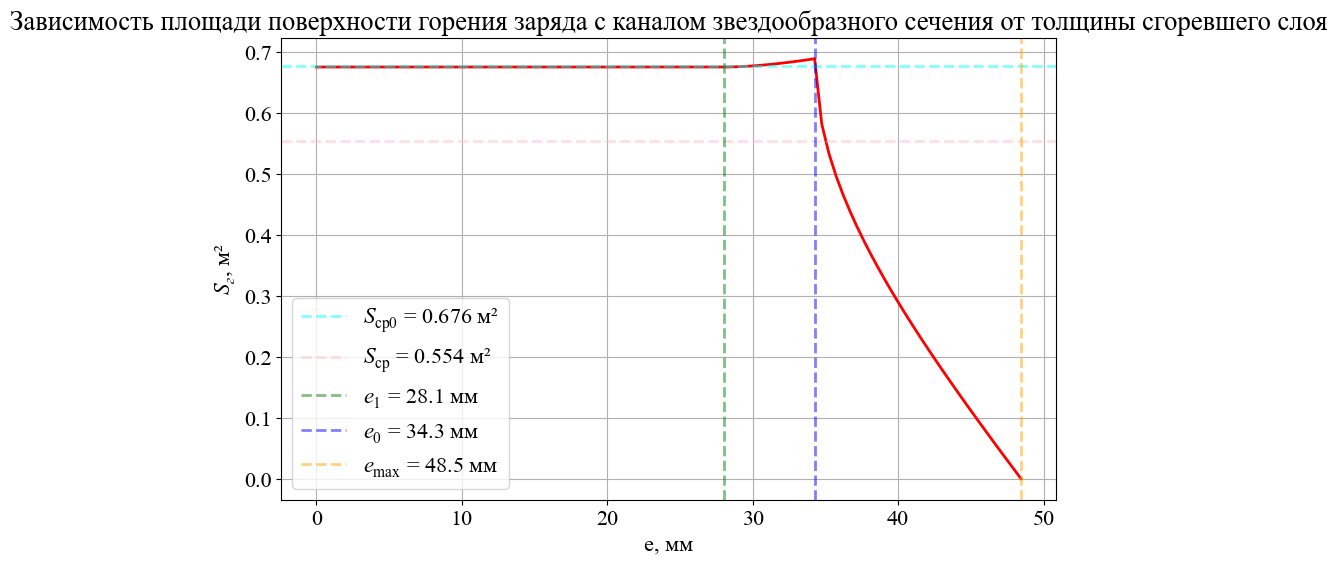

In [336]:
# Определяем переменные из объекта star (или star_2)
#s_sr0 = star_2.s_sr0
#s_sr = star_2.s_sr
#e_1 = star_2.e_1
#e_max = star_2.e_max

e_values = np.linspace(0, e_max, 100)
Sg_values = [star_2.S_g(e) for e in e_values]

plt.figure(figsize=(10, 6))
plt.plot(e_values*1e3, Sg_values, color="red", linewidth=2)

plt.axhline(y=s_sr0, color='cyan', linestyle='--', linewidth=2, alpha=0.5, 
            label=f'$S_{{\\mathrm{{ср0}}}}$ = {s_sr0:.3f} м²')
plt.axhline(y=s_sr, color='pink', linestyle='--', linewidth=2, alpha=0.5, 
            label=f'$S_{{\\mathrm{{ср}}}}$ = {s_sr:.3f} м²')
plt.axvline(x=e_1*1e3, color='green', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$e_1$ = {e_1*1e3:.1f} мм')
plt.axvline(x=e_0*1e3, color='blue', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$e_0$ = {e_0*1e3:.1f} мм')
plt.axvline(x=e_max*1e3, color='orange', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$e_{{\\mathrm{{max}}}}$ = {e_max*1e3:.1f} мм')

plt.xlabel('e, мм')
plt.ylabel('$S_г$, м²')
plt.title('Зависимость площади поверхности горения заряда с каналом звездообразного сечения от толщины сгоревшего слоя')
plt.grid(True)
plt.legend()
plt.show()

In [337]:
def kappa(e):
    return star_2.kappa(e)

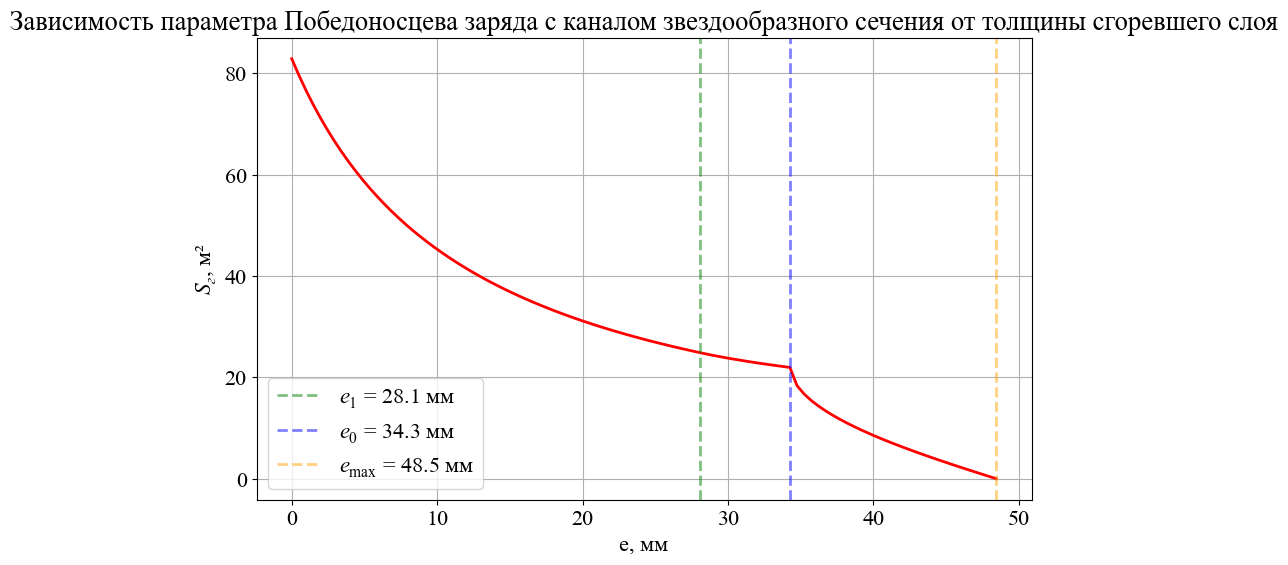

In [338]:
e_values = np.linspace(0, e_max, 100)
kappa_values = [kappa(e) for e in e_values]

plt.figure(figsize=(10, 6))
plt.plot(e_values*1e3, kappa_values, color="red", linewidth=2)

plt.axvline(x=e_1*1e3, color='green', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$e_1$ = {e_1*1e3:.1f} мм')
plt.axvline(x=e_0*1e3, color='blue', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$e_0$ = {e_0*1e3:.1f} мм')
plt.axvline(x=e_max*1e3, color='orange', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$e_{{\\mathrm{{max}}}}$ = {e_max*1e3:.1f} мм')

plt.xlabel('e, мм')
plt.ylabel('$S_г$, м²')
plt.title('Зависимость параметра Победоносцева заряда с каналом звездообразного сечения от толщины сгоревшего слоя')
plt.grid(True)
plt.legend()
plt.show()

# 2. Воспламенительный состав

In [339]:
from ODE_solvers import RungeKutta4
from prettytable import PrettyTable as ptable
import time
from scipy.integrate import trapezoid
from scipy.optimize import bisect
from scipy import optimize
from itertools import product
from multiprocessing import Pool
from tqdm import tqdm
import itertools
import warnings
warnings.filterwarnings('ignore')

In [340]:
if name == 'test':
    igniter = pd.read_csv('igniter test.csv').set_index('igniter').T
else:
    igniter = pd.read_csv('igniter.csv').set_index('igniter').T
class Igniter:
    def __init__(self,df):
        for key in df.index:
            setattr(self,key,df[key])
            
ign = Igniter(igniter.iloc[0])  

In [341]:
ds = pd.read_csv('dataset_star.csv').set_index('key').to_dict()

ds_values = ds['value']
ds_converted = {}
for key, value in ds_values.items():
    try:
        # Пробуем преобразовать в float
        ds_converted[key] = float(value)
    except (ValueError, TypeError):
        ds_converted[key] = value

[ c_p_init, R_g_init, dt_1, dt_2, t_1] = list(ds_converted.values())


In [342]:

G_ras_history = { '+20': []}
time_history = { '+20': []}
# начальные температуры
T_0 = {
       '+20': T_0_norm
}
# цвета для температур
cvet = {
        '+20': 'limegreen'
}


kappa_por = 100


In [343]:
F_ks = np.pi/4 * D_ks**2
d_eff = 4 * l_zar / kappa_0  # эффективный диаметр канала
d_kan = d_eff
F_kan = S_g(0) / kappa_0
F_kr = pi * D_kr**2 / 4
F_a = pi * D_a**2 / 4
q = F_kr / F_a

In [344]:
R_ign_eff = ign.R_g * (1 - ign.z)

In [345]:
p_nom_BORI_min = pr.p_ref*((pr.rho*s_sr0*0.95*pr.u_1*exp(pr.dlnu_dT*(T_0_norm-pr.T_ref))*sqrt(chi*R_eff*pr.T_p))/(mu_s*A_n*pr.p_ref*F_kr))**(1/(1-pr.nu))
p_nom_BORI_max = pr.p_ref*((pr.rho*s_sr0*1.05*pr.u_1*exp(pr.dlnu_dT*(T_0_norm-pr.T_ref))*sqrt(chi*R_eff*pr.T_p))/(mu_s*A_n*pr.p_ref*F_kr))**(1/(1-pr.nu))

print(f"p_nom_BORI_min = {p_nom_BORI_min/1e6:.5f} МПа")
print(f"p_nom_BORI_max = {p_nom_BORI_max/1e6:.5f} МПа")

p_nom_BORI_min = 11.03818 МПа
p_nom_BORI_max = 13.04188 МПа


# 3. ПРЯМАЯ ЗАДАЧА ВБ РДТТ

In [346]:
if name == 'С-5':
    e_0_ign = 0.6e-3
    omega_ign = 0.013
if name == 'С-8':
    e_0_ign = 0.6e-3
    omega_ign = 0.02
if name == 'С-13':
    e_0_ign = 0.6e-3
    omega_ign = 0.057
if name == '9М27Ф':
      e_0_ign = 0.6e-3
      omega_ign = 0.2
if name == '9М55':
    e_0_ign = 0.55e-3
    omega_ign = 0.3
if name == 'Х-15':
    e_0_ign = 0.6e-3
    omega_ign = 2.7


'''
    'test':'Test',
    'probnic':'Probnic',
    'С-5': 'НАР С-5',
    'С-8': 'НАР С-8',
    'С-13': 'НАР С-13',
    '9М27Ф': '"Ураган" 9М27Ф',
    'С-24': 'НАР С-24',
    '9М55': '"Смерч" 9М55',
    'Х-15': 'Авиационная аэробаллистическая ракета Х-15'

'''

'\n    \'test\':\'Test\',\n    \'probnic\':\'Probnic\',\n    \'С-5\': \'НАР С-5\',\n    \'С-8\': \'НАР С-8\',\n    \'С-13\': \'НАР С-13\',\n    \'9М27Ф\': \'"Ураган" 9М27Ф\',\n    \'С-24\': \'НАР С-24\',\n    \'9М55\': \'"Смерч" 9М55\',\n    \'Х-15\': \'Авиационная аэробаллистическая ракета Х-15\'\n\n'

In [347]:

if name == 'test' or name == 'probnic':
    #D_a = 0.144
    #D_kr = 0.06
    e_0_ign = 0.6e-3
    omega_ign = 0.14


In [348]:

print(f"Исходные данные")
print(f"D_ks = {D_ks}")
print(f"D_kr = {D_kr}")
print(f"D_a = {D_a}")
print(f"omega_t = {omega_t}")
print(f"e_0 = {e_0}")
print(f"n = {n}")
print(f"beta = {bet*180/pi}")
print(f"r = {r}")
print(f"l_zar = {l_zar}")
print(f"kappa_0 = {kappa_0}")
print(f"eps_f = {eps_f}")
print(f"xi_degr = {xi_degr}")

Исходные данные
D_ks = 0.2112
D_kr = 0.0492
D_a = 0.1787
omega_t = 45.6
e_0 = 0.0343
n = 7.0
beta = 35.56
r = 0.0065
l_zar = 0.9978
kappa_0 = 82.87
eps_f = 0.76738
xi_degr = 0.13522


In [349]:
import time
start_time = time.time()

In [350]:
kappa_por = 100
d_ign = 5 *e_0_ign
c_ign = 0.75 * e_0_ign

G_ras_history = {'+20': []}
time_history = {'+20': []}
P_history = {'+20': []}

# начальные температуры
T_0 = {
       '+20': T_0_norm,
       }
# цвета для температур
cvet = {
        '+20': 'limegreen',
        }

In [351]:
#### для двояковыпуклой таблетки (одного зерна)

# радиус r таблетки и высота h и радиус R сферических сегментов таблетки
r_ign = d_ign/2
h_sph_ign = e_0_ign - c_ign/2
R_sph_ign = (r_ign**2 + h_sph_ign**2)/2/h_sph_ign

# ф-ия площади пов-ти горения от толщины сгоревшего свода для ПЕРВОЙ стадии
def S_1(e):
    h_1 = R_sph_ign - e - sqrt((R_sph_ign - e)**2 - (r_ign - e)**2)
    c_1 = 2*(e_0_ign - e - h_1)
    return 4*pi*(R_sph_ign - e)*h_1 + 2*pi*(r_ign - e)*c_1

# условие конца ПЕРВОЙ стадии с_1(e_ign_1) = 0  ---->  e_ign_1 = ...
e_ign_1 = (R_sph_ign**2 - r_ign**2 - (R_sph_ign - e_0_ign)**2)/2/(R_sph_ign - r_ign)

# ф-ия площади пов-ти горения от толщины сгоревшего свода для ВТОРОЙ стадии
def S_2(e):
    return 4*pi*(R_sph_ign - e)*(e_0_ign - e)

# объём ОДНОЙ таблетки (объём единичного зерна воспламенителя)
V_ign_1 = pi*r_ign**2*c_ign + 2*pi*h_sph_ign**2*(R_sph_ign - h_sph_ign/3)

# масса единичного зерна воспламенителя
omega_ign_1 = ign.rho*V_ign_1

# закон изменения площади пов-ти горения единичного зерна воспламенителя
def S_ign_1(e):
    if e <= e_ign_1:
        return S_1(e)
    else:
        return S_2(e)

# суммарная площадь пов-ти горения воспламенителя
def S_g_ign(e):
    return omega_ign/omega_ign_1*S_ign_1(e)

In [352]:
F_kr = pi*D_kr**2/4
F_a  = pi*D_a**2 /4
q_a = F_kr/F_a

R_eff = pr.R_g*(1 - pr.z)
R_ign_eff = ign.R_g*(1 - ign.z)

# Постоянная расхода
A_n = sqrt(pr.n_1 * (2 / (pr.n_1 + 1))**((pr.n_1 + 1) / (pr.n_1 - 1)))


In [353]:

# Проверяем значения функции в разных точках
def f(x):
    return q_a-q_gdf(x,pr.n_a_fr)
lambda_a = bisect(f, 2, 3, xtol=1e-12, maxiter=100)
print(f"lamnda_a = {lambda_a:.5f}")

lamnda_a = 2.42616


In [354]:

# эффективные значения газовой постоянной, с учётом наличия конденсированной фазы в продуктах сгорания


def G(x):
    p_crit = p_h / pi_gdf(1.0, pr.n_1)
    if x[0] < p_crit:
        ratio = p_h / x[0]
        term_inside = 1.0 - ratio**((pr.n_1 - 1) / pr.n_1)
        return (x[0] * F_kr / sqrt(x[4] * x[1])) * ratio**(1.0 / pr.n_1) * sqrt(2.0 * pr.n_1 / (pr.n_1 - 1.0) * term_inside)
    else:

        return A_n * x[0] * F_kr / sqrt(x[4] * x[1])

def koff(x,n,z):
    return epsilon_gdf(x,n)*(x**2+1)*zeta(x,n,z)

def P(x):
    if (x[0] * pi_gdf(lambda_a, pr.n_a_fr) >= 0.3 * p_h):
        return x[0] * F_a * koff(lambda_a, pr.n_a_fr,pr.z) - p_h * F_a
    else:
        return 0

In [355]:

# Система
def system(t, x, T_0,temp_key=None):
    # x[0] = p; x[1] = T;     x[2] = W; x[3] = c_p; 
    # x[4] = R; x[5] = e_ign; x[6] = e; x[7] = eta_T
    # плотность газов из ур-ия состояния совершенного газа
    rho = x[0]/(x[4]*x[1])
    # показатель адиабаты продуктов сгорания
    k = x[3]/(x[3] - x[4])
    # скорость горения основного заряда
    u = pr.u_1*(x[0]/pr.p_ref)**pr.nu*np.exp(pr.dlnu_dT*(T_0 - pr.T_ref))
    # скорость горения воспламенительного состава
    u_ign = ign.u_1*(x[0]/ign.p_ref)**ign.nu*np.exp(ign.dlnu_dT*(T_0 - pr.T_ref))
    # секундный массоприход при сгорании основного заряда
    if (kappa(x[6])>=kappa_por):
        phi_kapa = 1 + 0.003*(kappa(x[6]) - kappa_por)
    else:
        phi_kapa = 1  
    G_T = S_g(x[6])*u*pr.rho*phi_kapa*np.heaviside(e_max - x[6],0.5)*(1 - np.heaviside(pr.T_ign - T_0 - sqrt(x[7]),0.5))
    # секундный массоприход при сгорании воспламенительного состава
    G_ign = S_g_ign(x[5])*u_ign*ign.rho*np.heaviside(e_0_ign - x[5],0.5)   
    # число Рейнольдса
    Re = G_ign*d_kan/(F_kan* ign.mu_g)
    # число Прандтля
    Pr = ign.c_pg*ign.mu_g/ign.lambda_g
    # число Нуссельта
    Nu = 0.023*Re**0.8*Pr**0.4
    # плотность теплового потока
    q_zar = Nu*ign.lambda_g/d_kan*(x[1] - T_0 - sqrt(x[7]))
    # X и Y
    X = G_ign*ign.c_p*(ign.T_p - x[1]) + G_T*pr.c_p*(pr.T_p - x[1]) - q_zar*S_g(0)*np.heaviside(pr.T_ign - T_0 - sqrt(x[7]),0.5)
    Y = G_ign*R_ign_eff*x[1] + G_T*R_eff*x[1] - x[0]/rho*G(x) - x[0]*(G_ign/ign.rho + G_T/pr.rho)
    # x[0] = p; x[1] = T;     x[2] = W; x[3] = c_p; 
    # x[4] = R; x[5] = e_ign; x[6] = e; x[7] = eta_T
    dx_dt = np.zeros(8)
    dx_dt[0] = (k - 1)/x[2]*(X + k/(k - 1)*Y)                                                            # dp/dt
    dx_dt[1] = (k - 1)/(rho*x[2]*x[4])*(X + Y)                                                           # dT/dt
    dx_dt[2] = G_ign/ign.rho + G_T/pr.rho                                                                # dW/dt
    dx_dt[3] = 1/(rho*x[2])*(G_ign*(ign.c_p - x[3]) + G_T*(pr.c_p - x[3]))                                  # dc_p/dt  
    dx_dt[4] = 1/(rho*x[2])*(G_ign*(R_ign_eff - x[4]) + G_T*(R_eff - x[4]))                              # dR/dt
    dx_dt[5] = u_ign*np.heaviside(e_0_ign - x[5],0.5)                                                    # de_ign/dt
    dx_dt[6] = u*phi_kapa*np.heaviside(e_max - x[6],0.5)*(1 - np.heaviside(pr.T_ign - T_0 - sqrt(x[7]),0.5))  # de/dt
    dx_dt[7] = 2*q_zar**2/(pr.c_pr*pr.lambda_pr*pr.rho)*np.heaviside(pr.T_ign - T_0 - sqrt(x[7]),0.5)               # deta_T/dt
    return dx_dt


In [356]:
# начальный свободный объём КС
W_0 = pi/12*D_ks**3 + pi/4*D_ks**2*l_zar - omega_t/pr.rho

In [357]:
# условие остановки расчёта 1-го этапа - должно возвращать True для продолжения
def stop1(t, x):
    return t_1 - t # Продолжать пока t < 0.25 с

# условие остановки расчёта 2-го этапа  
def stop2(t, x):
    return x[0] - 2e5  # Продолжать пока давление > 0.2 МПа

# Функции системы для разных температур
def sys_min(t, x):
    return system(t, x, T_0['-50'], '-50')

def sys_norm(t, x):
    return system(t, x, T_0['+20'], '+20')

def sys_max(t, x):
    return system(t, x, T_0['+50'], '+50')

# Функции для дополнительных параметров в отчете
def report(t, x):
    return [kappa(x[6]), x[0]/1e6,G(x),P(x)]  

In [358]:
# Решаем систему для разных температур (первый этап)
init_norm = [p_h, T_0['+20'], W_0, c_p_init, R_g_init, 0, 0, 0]  # T0 = +20°C
res_norm_1 = RungeKutta4(init_norm, sys_norm, 0, dt_1, 100_000, stop1, report)

# Продолжаем решение для второго этапа
res_norm_2 = RungeKutta4(res_norm_1[-2, 1:9], sys_norm, res_norm_1[-2, 0], dt_2, 100_000, stop2, report)

In [359]:
# Объединяем результаты
def combine_results(res1, res2):
    t_combined = np.concatenate([res1[:, 0], res2[:, 0]])
    vars_combined = np.concatenate([res1[:, 1:9], res2[:, 1:9]], axis=0)  # 8 переменных состояния
    report_combined = np.concatenate([res1[:, 9:13], res2[:, 9:13]], axis=0)  # 4 дополнительных параметра
    return np.column_stack([t_combined, vars_combined, report_combined])

In [360]:
res_norm_combined = combine_results(res_norm_1, res_norm_2) 

# Создаем DataFrame для удобной работы с результатами
columns = ['t', 'p', 'T', 'W', 'c_p', 'R', 'e_ign', 'e', 'eta_T', 'kapa', 'p_MPa', 'G', 'P']
df_norm = pd.DataFrame(res_norm_combined, columns=columns)

Результаты 5 раздела + кривые давления

+-------+---------+----------+---------+
| Точка |  $t$, c | $p$, МПа |  $T$, К |
+-------+---------+----------+---------+
|  ign  | 0.00605 | 2.16602  | 2381.60 |
|  max  | 0.02735 | 13.57936 | 2984.81 |
|  осн  |  2.615  | 12.39522 | 2966.77 |
|   п   |  4.600  | 0.199325 | 2922.08 |
+-------+---------+----------+---------+
Время расчета программы: 1.23 с


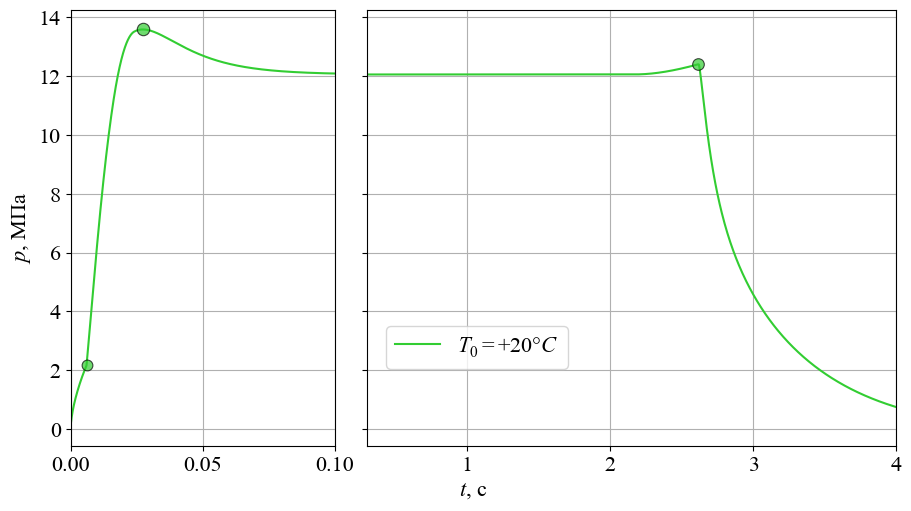

In [361]:
# для кривых давления разбиваем на два сабплота в соответствующем масштабе
fig = plt.figure(figsize=(9, 5), constrained_layout=True)
gs = fig.add_gridspec(3, 12)

ax1 = fig.add_subplot(gs[:, 0:4])
ax1.set_xlim(0, 0.1)

ax1.set_ylabel('$p$, МПа')
ax1.grid()
ax2 = fig.add_subplot(gs[:, 4:12])
for ylabel_i in ax2.axes.get_yticklabels():
    ylabel_i.set_fontsize(0.0)
    ylabel_i.set_visible(False)
ax2.set_xlim(0.3,4)

ax2.set_xlabel('$t$, с')
ax2.xaxis.set_label_coords(.2, -.08)
ax2.grid()

# Цвета и маркеры для разных точек
markers = {
    'ign': 'o',      
    'max': 'o',      
    'осн': 'o',      
    'п': 'o'         
}

sizes = {
    'ign': 60,
    'max': 80,
    'осн': 70,
    'п': 60
}

# Обновляем обработку результатов с использованием DataFrame
ar_t, ar_p, ar_T, ar_W, ar_c_p, ar_R, ar_e_ign, ar_e, ar_eta_T = {}, {}, {}, {}, {}, {}, {}, {}, {}

results_dict = {
    '+20': df_norm
}
print('='*100)
print('Результаты 5 раздела + кривые давления')
print('='*100)
print()
for temp0, df in results_dict.items():
    ar_t[temp0] = df['t'].values
    ar_p[temp0] = df['p'].values
    ar_T[temp0] = df['T'].values
    ar_W[temp0] = df['W'].values
    ar_c_p[temp0] = df['c_p'].values
    ar_R[temp0] = df['R'].values
    ar_e_ign[temp0] = df['e_ign'].values
    ar_e[temp0] = df['e'].values
    ar_eta_T[temp0] = df['eta_T'].values
    
   
    
    # Построение кривых давления на обоих осях
    ax1.plot(ar_t[temp0], ar_p[temp0]/1e6, color=cvet[temp0])
    ax2.plot(ar_t[temp0], ar_p[temp0]/1e6, color=cvet[temp0], label=f'$T_0 = {temp0}°C$')
    
    try:
        i_ign = np.argwhere(ar_e[temp0] > 0)[0][0]
        i_max = np.argwhere(ar_p[temp0] == np.max(ar_p[temp0]))[-1][0]
        i_osn = np.argwhere(ar_e[temp0] <= e_0)[-1][0]
        i_end = np.argwhere(ar_p[temp0] <= 2e5)[-1][-1]
    except IndexError:
        i_ign = 0
        i_max = 0 
        i_osn = 0

    t_ign = ar_t[temp0][i_ign]
    t_max = ar_t[temp0][i_max]
    t_osn = ar_t[temp0][i_osn]
    t_end = ar_t[temp0][i_end]

    p_ign = ar_p[temp0][i_ign]/1e6
    p_max = ar_p[temp0][i_max]/1e6
    p_osn = ar_p[temp0][i_osn]/1e6
    p_end = ar_p[temp0][i_end]/1e6

    T_ign = ar_T[temp0][i_ign]
    T_max = ar_T[temp0][i_max]
    T_osn = ar_T[temp0][i_osn]
    T_end = ar_T[temp0][i_end]

    # Добавляем характерные точки на графики
    points_data = {
        'ign': (t_ign, p_ign),
        'max': (t_max, p_max), 
        'осн': (t_osn, p_osn),
        'п': (t_end, p_end)
    }
    
    for point_name, (t_point, p_point) in points_data.items():
        if t_point <= 0.1:
            ax1.scatter(t_point, p_point, marker=markers[point_name], s=sizes[point_name], 
                       color=cvet[temp0], edgecolor='black', linewidth=0.8, zorder=5,
                       alpha=0.7)
        ax2.scatter(t_point, p_point, marker=markers[point_name], s=sizes[point_name],
               color=cvet[temp0], edgecolor='black', linewidth=0.8, zorder=5,
               alpha=0.7)  

    # Создаем таблицу с округленными значениями
    tbl = ptable()
    tbl.add_column('Точка', ['ign', 'max', 'осн', 'п'])
    tbl.add_column('$t$, c', [f"{t_ign:.5f}", f"{t_max:.5f}", f"{t_osn:.3f}", f"{t_end:.3f}"])
    tbl.add_column('$p$, МПа', [f"{p_ign:.5f}", f"{p_max:.5f}", f"{p_osn:.5f}", f"{p_end:.6f}"])
    tbl.add_column('$T$, К', [f"{T_ign:.2f}", f"{T_max:.2f}", f"{T_osn:.2f}", f"{T_end:.2f}"])
    print(tbl)
    

print("Время расчета программы: %s с" % (np.round(time.time() - start_time, 3)))
ax2.legend(loc='best')
ax2.legend(bbox_to_anchor=(0.4, 0.3))
plt.show()

In [362]:
F_kr = D_kr**2/4*pi
P_NOM_BORI = pr.p_ref*((pr.rho*star_2.s_sr0*pr.u_1*exp(pr.dlnu_dT*(T_0_norm-pr.T_ref))*sqrt(chi*R_eff*pr.T_p))/(mu_s*A_n*pr.p_ref*F_kr))**(1/(1-pr.nu))
print(f"p_nom_BORI = {P_NOM_BORI/1e6:.5f} МПа")
p_a_BORI = P_NOM_BORI *pi_gdf(lambda_a, pr.n_a_fr)
print(f"p_a_BORI = {p_a_BORI/1e6:.5f} МПа")
print(f"s_sr0 = {star_2.s_sr0:.5f}")
print(f"F_kr = {F_kr:.8f}")

p_nom_BORI = 12.02333 МПа
p_a_BORI = 0.10009 МПа
s_sr0 = 0.67628
F_kr = 0.00190117


In [363]:
df = df_norm
t = df_norm['t'].values
p = df_norm['p'].values
P = df_norm['P'].values
G = df_norm['G'].values
i_ign = np.argwhere(df['e'].values > 0)[0][0]           # момент зажигания
i_max = np.argwhere(df['p'].values == df['p'].max())[-1][0]  # максимум давления
i_osn = np.argwhere(df['e'].values <= e_0)[-1][0]       # конец горения основного заряда
i_end = np.argwhere(df['p'].values <= 2e5)[-1][-1]      # спад до 0.2 МПа

t_ign = df['t'].values[i_ign]
t_osn = df['t'].values[i_osn]
t_max = df['t'].values[i_max]
t_end = df['t'].values[i_end]

In [364]:
# Интегрируем методом трапеций
I_p_norm_degr = trapezoid(df_norm['P'], df_norm['t'])  
print(f"I_p^+20 = {I_p_norm_degr/1e3:.3f} кН*с")
m_norm = trapezoid(df_norm['G'], df_norm['t'])  
print()
I_sp_norm_degr = I_p_norm_degr / m_norm
print(f"I_уд^+20 = {I_sp_norm_degr:.3f} м/с")


I_p^+20 = 106.913 кН*с

I_уд^+20 = 2337.894 м/с


In [365]:
# Интегрируем методом трапеций
I_p_norm = trapezoid(P[0:i_osn+1], t[0:i_osn+1]) 
print(f"I_p^+20 = {I_p_norm/1e3:.3f} кН*с")
m_norm = trapezoid(G[0:i_osn+1], t[0:i_osn+1])  
print()
I_sp_norm = I_p_norm / m_norm
print(f"I_уд^+20 = {I_sp_norm:.3f} м/с")


I_p^+20 = 97.026 кН*с

I_уд^+20 = 2477.352 м/с


In [366]:


print(f"t_osn = {t_osn:.5f} с")
print(f"t_ign = {t_ign:.5f} с")

dt_interval = t_osn - t_max
print(f"Интеграл давления = {trapezoid(p[i_ign:i_osn+1], t[i_ign:i_osn+1])/1e6:.5f} МПа*с")
print(f"Интервал времени = {dt_interval:.5f} с")
p_NOM = trapezoid(p[i_max:i_osn+1], t[i_max:i_osn+1]) / dt_interval
print()
print(f'p_ном = {p_NOM/1e6:.5f} МПа')
p_A = p_NOM *pi_gdf(lambda_a, pr.n_a_fr)
print(f"lambda_a ={lambda_a:.5f}")
print(f"p_a = {p_A/1e6:.5f} МПа")

t_osn = 2.61500 с
t_ign = 0.00605 с
Интеграл давления = 31.48897 МПа*с
Интервал времени = 2.58765 с

p_ном = 12.08555 МПа
lambda_a =2.42616
p_a = 0.10061 МПа


Результаты 5 раздела + кривые давления

+-------+---------+----------+---------+
| Точка |  $t$, c | $p$, МПа |  $T$, К |
+-------+---------+----------+---------+
|  ign  | 0.00605 | 0.01803  | 2381.60 |
|  max  | 0.02735 | 0.11305  | 2984.81 |
|  осн  |  2.615  | 0.10319  | 2966.77 |
|   п   |  4.600  | 0.001659 | 2922.08 |
+-------+---------+----------+---------+
Время расчета программы: 1.589 с


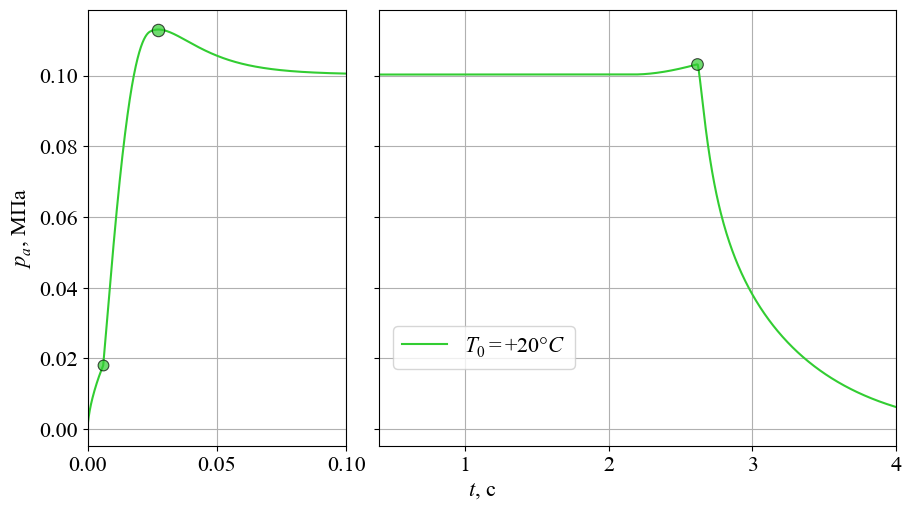

In [367]:
# для кривых давления разбиваем на два сабплота в соответствующем масштабе
fig = plt.figure(figsize=(9, 5), constrained_layout=True)
gs = fig.add_gridspec(3, 12)

ax1 = fig.add_subplot(gs[:, 0:4])
ax1.set_xlim(0, 0.1)

ax1.set_ylabel('$p_a$, МПа')
ax1.grid()
ax2 = fig.add_subplot(gs[:, 4:12])
for ylabel_i in ax2.axes.get_yticklabels():
    ylabel_i.set_fontsize(0.0)
    ylabel_i.set_visible(False)
ax2.set_xlim(0.4,4)

ax2.set_xlabel('$t$, с')
ax2.xaxis.set_label_coords(.2, -.08)
ax2.grid()

# Цвета и маркеры для разных точек
markers = {
    'ign': 'o',      
    'max': 'o',      
    'осн': 'o',      
    'п': 'o'         
}

sizes = {
    'ign': 60,
    'max': 80,
    'осн': 70,
    'п': 60
}

# Обновляем обработку результатов с использованием DataFrame
ar_t, ar_p, ar_T, ar_W, ar_c_p, ar_R, ar_e_ign, ar_e, ar_eta_T = {}, {}, {}, {}, {}, {}, {}, {}, {}

results_dict = {
    '+20': df_norm
}
print('='*100)
print('Результаты 5 раздела + кривые давления')
print('='*100)
print()
for temp0, df in results_dict.items():
    ar_t[temp0] = df['t'].values
    ar_p[temp0] = df['p'].values
    ar_T[temp0] = df['T'].values
    ar_W[temp0] = df['W'].values
    ar_c_p[temp0] = df['c_p'].values
    ar_R[temp0] = df['R'].values
    ar_e_ign[temp0] = df['e_ign'].values
    ar_e[temp0] = df['e'].values
    ar_eta_T[temp0] = df['eta_T'].values
    
   
    
    # Построение кривых давления на обоих осях
    ax1.plot(ar_t[temp0], ar_p[temp0]/1e6*pi_gdf(lambda_a, pr.n_a_fr), color=cvet[temp0])
    ax2.plot(ar_t[temp0], ar_p[temp0]/1e6*pi_gdf(lambda_a, pr.n_a_fr), color=cvet[temp0], label=f'$T_0 = {temp0}°C$')
    
    try:
        i_ign = np.argwhere(ar_e[temp0] > 0)[0][0]
        i_max = np.argwhere(ar_p[temp0] == np.max(ar_p[temp0]))[-1][0]
        i_osn = np.argwhere(ar_e[temp0] <= e_0)[-1][0]
        i_end = np.argwhere(ar_p[temp0] <= 2e5)[-1][-1]
    except IndexError:
        i_ign = 0
        i_max = 0 
        i_osn = 0

    t_ign = ar_t[temp0][i_ign]
    t_max = ar_t[temp0][i_max]
    t_osn = ar_t[temp0][i_osn]
    t_end = ar_t[temp0][i_end]

    p_ign = ar_p[temp0][i_ign]/1e6*pi_gdf(lambda_a, pr.n_a_fr)
    p_max = ar_p[temp0][i_max]/1e6*pi_gdf(lambda_a, pr.n_a_fr)
    p_osn = ar_p[temp0][i_osn]/1e6*pi_gdf(lambda_a, pr.n_a_fr)
    p_end = ar_p[temp0][i_end]/1e6*pi_gdf(lambda_a, pr.n_a_fr)

    T_ign = ar_T[temp0][i_ign]
    T_max = ar_T[temp0][i_max]
    T_osn = ar_T[temp0][i_osn]
    T_end = ar_T[temp0][i_end]

    # Добавляем характерные точки на графики
    points_data = {
        'ign': (t_ign, p_ign),
        'max': (t_max, p_max), 
        'осн': (t_osn, p_osn),
        'п': (t_end, p_end)
    }
    
    for point_name, (t_point, p_point) in points_data.items():
        if t_point <= 0.1:
            ax1.scatter(t_point, p_point, marker=markers[point_name], s=sizes[point_name], 
                       color=cvet[temp0], edgecolor='black', linewidth=0.8, zorder=5,
                       alpha=0.7)
        ax2.scatter(t_point, p_point, marker=markers[point_name], s=sizes[point_name],
               color=cvet[temp0], edgecolor='black', linewidth=0.8, zorder=5,
               alpha=0.7)  

    # Создаем таблицу с округленными значениями
    tbl = ptable()
    tbl.add_column('Точка', ['ign', 'max', 'осн', 'п'])
    tbl.add_column('$t$, c', [f"{t_ign:.5f}", f"{t_max:.5f}", f"{t_osn:.3f}", f"{t_end:.3f}"])
    tbl.add_column('$p$, МПа', [f"{p_ign:.5f}", f"{p_max:.5f}", f"{p_osn:.5f}", f"{p_end:.6f}"])
    tbl.add_column('$T$, К', [f"{T_ign:.2f}", f"{T_max:.2f}", f"{T_osn:.2f}", f"{T_end:.2f}"])
    print(tbl)
    

print("Время расчета программы: %s с" % (np.round(time.time() - start_time, 3)))
ax2.legend(loc='best')
ax2.legend(bbox_to_anchor=(0.4, 0.3))
plt.show()

Результаты 5 раздела + кривые давления

+-------+---------+----------+---------+
| Точка |  $t$, c | $P$, кН  |  $T$, К |
+-------+---------+----------+---------+
|  ign  | 0.00605 | 0.00000  | 2381.60 |
|  max  | 0.02735 | 42.15901 | 2984.81 |
|  осн  |  2.615  | 38.26396 | 2966.77 |
|   п   |  4.600  | 0.000000 | 2922.08 |
+-------+---------+----------+---------+
Время расчета программы: 1.845 с


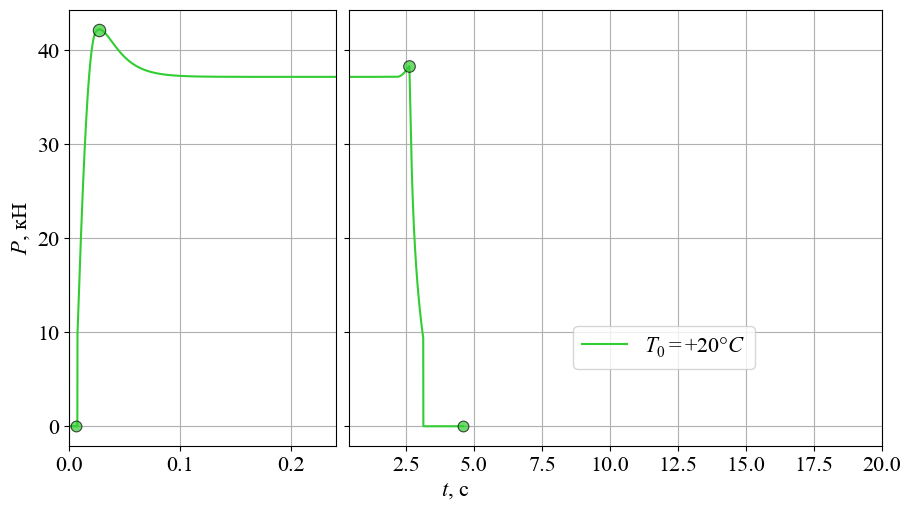

In [368]:
# для кривых давления разбиваем на два сабплота в соответствующем масштабе
fig = plt.figure(figsize=(9, 5), constrained_layout=True)
gs = fig.add_gridspec(3, 12)

ax1 = fig.add_subplot(gs[:, 0:4])
ax1.set_xlim(0, 0.24)

ax1.set_ylabel('$P$, кН')
ax1.grid()
ax2 = fig.add_subplot(gs[:, 4:12])
for ylabel_i in ax2.axes.get_yticklabels():
    ylabel_i.set_fontsize(0.0)
    ylabel_i.set_visible(False)
ax2.set_xlim(0.4,20)

ax2.set_xlabel('$t$, с')
ax2.xaxis.set_label_coords(.2, -.08)
ax2.grid()

# Цвета и маркеры для разных точек
markers = {
    'ign': 'o',      
    'max': 'o',      
    'осн': 'o',      
    'п': 'o'         
}

sizes = {
    'ign': 60,
    'max': 80,
    'осн': 70,
    'п': 60
}

# Обновляем обработку результатов с использованием DataFrame
ar_t, ar_p, ar_T, ar_W, ar_c_p, ar_R, ar_e_ign, ar_e, ar_eta_T,ar_P = {}, {}, {}, {}, {}, {}, {}, {}, {},{}

results_dict = {
    '+20': df_norm
}
print('='*100)
print('Результаты 5 раздела + кривые давления')
print('='*100)
print()
for temp0, df in results_dict.items():
    ar_t[temp0] = df['t'].values
    ar_p[temp0] = df['p'].values
    ar_T[temp0] = df['T'].values
    ar_W[temp0] = df['W'].values
    ar_c_p[temp0] = df['c_p'].values
    ar_R[temp0] = df['R'].values
    ar_e_ign[temp0] = df['e_ign'].values
    ar_e[temp0] = df['e'].values
    ar_eta_T[temp0] = df['eta_T'].values
    ar_P[temp0] = df['P'].values
   
    
    # Построение кривых давления на обоих осях
    ax1.plot(ar_t[temp0], ar_P[temp0]/1e3, color=cvet[temp0])
    ax2.plot(ar_t[temp0], ar_P[temp0]/1e3, color=cvet[temp0], label=f'$T_0 = {temp0}°C$')
    
    try:
        i_ign = np.argwhere(ar_e[temp0] > 0)[0][0]
        i_max = np.argwhere(ar_p[temp0] == np.max(ar_p[temp0]))[-1][0]
        i_osn = np.argwhere(ar_e[temp0] <= e_0)[-1][0]
        i_end = np.argwhere(ar_p[temp0] <= 2e5)[-1][-1]
    except IndexError:
        i_ign = 0
        i_max = 0 
        i_osn = 0

    t_ign = ar_t[temp0][i_ign]
    t_max = ar_t[temp0][i_max]
    t_osn = ar_t[temp0][i_osn]
    t_end = ar_t[temp0][i_end]

    P_ign = ar_P[temp0][i_ign]/1e3
    P_max = ar_P[temp0][i_max]/1e3
    P_osn = ar_P[temp0][i_osn]/1e3
    P_end = ar_P[temp0][i_end]/1e3

    T_ign = ar_T[temp0][i_ign]
    T_max = ar_T[temp0][i_max]
    T_osn = ar_T[temp0][i_osn]
    T_end = ar_T[temp0][i_end]

    # Добавляем характерные точки на графики
    points_data = {
        'ign': (t_ign, P_ign),
        'max': (t_max, P_max), 
        'осн': (t_osn, P_osn),
        'п': (t_end, P_end)
    }
    
    for point_name, (t_point, P_point) in points_data.items():
        if t_point <= 0.1:
            ax1.scatter(t_point, P_point, marker=markers[point_name], s=sizes[point_name], 
                       color=cvet[temp0], edgecolor='black', linewidth=0.8, zorder=5,
                       alpha=0.7)
        ax2.scatter(t_point, P_point, marker=markers[point_name], s=sizes[point_name],
               color=cvet[temp0], edgecolor='black', linewidth=0.8, zorder=5,
               alpha=0.7)  

    # Создаем таблицу с округленными значениями
    tbl = ptable()
    tbl.add_column('Точка', ['ign', 'max', 'осн', 'п'])
    tbl.add_column('$t$, c', [f"{t_ign:.5f}", f"{t_max:.5f}", f"{t_osn:.3f}", f"{t_end:.3f}"])
    tbl.add_column('$P$, кН', [f"{P_ign:.5f}", f"{P_max:.5f}", f"{P_osn:.5f}", f"{P_end:.6f}"])
    tbl.add_column('$T$, К', [f"{T_ign:.2f}", f"{T_max:.2f}", f"{T_osn:.2f}", f"{T_end:.2f}"])
    print(tbl)
    

print("Время расчета программы: %s с" % (np.round(time.time() - start_time, 3)))
ax2.legend(loc='best')
ax2.legend(bbox_to_anchor=(0.4, 0.3))
plt.show()

In [369]:
print(f"n = {n}")
print(f"beta = {bet*180/pi}")

n = 7.0
beta = 35.56


In [370]:
print(f"D_ks = {D_ks}")
print(f"D_kr = {D_kr}")
print(f"D_a = {D_a}")
print(f"omega_t = {omega_t}")
print(f"e_0 = {e_0}")
print(f"r = {r}")
print(f"l_zar = {l_zar}")

D_ks = 0.2112
D_kr = 0.0492
D_a = 0.1787
omega_t = 45.6
e_0 = 0.0343
r = 0.0065
l_zar = 0.9978


In [371]:
print(f"kappa_0 = {kappa_0}")
print(f"lambda_a ={lambda_a:.4f}")
print(f"eps_f = {eps_f}")
print(f"xi_degr ={xi_degr}")

kappa_0 = 82.87
lambda_a =2.4262
eps_f = 0.76738
xi_degr =0.13522


In [372]:
print(f"omega_ign = {omega_ign}")
print(f"e_0_ign = {e_0_ign}")

omega_ign = 0.2
e_0_ign = 0.0006


In [373]:
print('Аналитическое решение (без учета дегрессивных остатков)')
print(f"t_осн = {t_osn_analit} с")
print(f"t_p = {t_p_analit} с")
print(f"I_p = {I_p/1e3:.3f} кН*с")
print(f"I_уд = {I_ud:.3f} м/с")

Аналитическое решение (без учета дегрессивных остатков)
t_осн = 2.619 с
t_p = 4.2798 с
I_p = 99.022 кН*с
I_уд = 2511.090 м/с


In [374]:
print('Численное решение (без учета дегрессивных остатков)')
print(f"t_осн = {t_osn:.4f} с")
print(f"t_п = {t_end:.4f} с")
print(f"I_p = {I_p_norm/1e3:.3f} кН*с")
print(f"I_уд = {I_sp_norm:.3f} м/с")

Численное решение (без учета дегрессивных остатков)
t_осн = 2.6150 с
t_п = 4.6000 с
I_p = 97.026 кН*с
I_уд = 2477.352 м/с


In [375]:
print('Численное решение (с учетом дегрессивных остатков)')
print(f"I_p^+20 = {I_p_norm_degr/1e3:.3f} кН*с")
print(f"I_уд^+20 = {I_sp_norm_degr:.3f} м/с")

Численное решение (с учетом дегрессивных остатков)
I_p^+20 = 106.913 кН*с
I_уд^+20 = 2337.894 м/с


In [376]:
print(f"p_a = {p_A/1e6:.5f} МПа")
print(f"p_ном = {p_NOM/1e6:.5f} МПа")

p_a = 0.10061 МПа
p_ном = 12.08555 МПа


In [377]:
print(f'p_ном_БОРИ = {P_NOM_BORI/1e6:.5f} МПа')
print(f"p_a_BORI = {p_a_BORI/1e6:.5f} МПа")


p_ном_БОРИ = 12.02333 МПа
p_a_BORI = 0.10009 МПа
